# Sesión de AIDP
### Preparando una buena base de datos sobre la Copa del Mundo

En este notebook verás, paso a paso:
- Ingesta de datos
- Creación de la capa Bronze
-- Datos crudos del catálogo
-- Profiling + calidad
- Limpieza y actualización de la capa Silver
-- Limpieza + estandarización
-- Datos confiables
- Inserción de la capa Gold
-- Métricas de negocio. Dashboards, gráficos, resultados de modelos

Todo organizado de forma simple para ejecutar celda por celda.

---

### Capa Bronze
- Observabilidad de los datos
- Calidad de los datos
- Enriquecimiento del catálogo de datos

### Lectura del csv y almacenamiento en archivo temporal

In [113]:
import requests
import pandas as pd

url = "https://objectstorage.us-chicago-1.oraclecloud.com/n/idajmumkp9ca/b/DeepDiveWorkshopData/o/fifa_players.csv"

response = requests.get(url)

with open("/tmp/fifa_players.csv", "wb") as f:
    f.write(response.content)

csv = pd.read_csv("/tmp/fifa_players.csv")

### Tratamiento del csv para el estándar 

In [114]:
def spark_to_spark_sql_type(spark_type):
    t = str(spark_type)
    
    if "StringType" in t:
        return "STRING"
    elif "IntegerType" in t:
        return "INT"
    elif "LongType" in t:
        return "BIGINT"
    elif "DoubleType" in t:
        return "DOUBLE"
    elif "FloatType" in t:
        return "FLOAT"
    elif "BooleanType" in t:
        return "BOOLEAN"
    elif "DateType" in t:
        return "DATE"
    elif "TimestampType" in t:
        return "TIMESTAMP"
    else:
        return "STRING"

### Generación del DDL para crear tabla con el mismo formato, columnas y tipos del csv

In [115]:
def generate_create_table(df, table_name):
    columns = []
    
    for field in df.schema.fields:
        col_name = field.name
        col_type = spark_to_spark_sql_type(field.dataType)
        columns.append(f"{col_name} {col_type}")
    
    cols_sql = ",\n  ".join(columns)
    
    ddl = f"""
    CREATE TABLE {table_name} (
      {cols_sql}
    )
    """
    
    return ddl

### Ingesta de la capa Bronze -> raw
Nota que incluso en esta capa, fue necesario algún procesamiento.
- Procesamiento de los tipos del csv para Spark
- Limpieza de las columnas con caracteres especiales
- Creación del schema de la tabla y de la tabla
- Escritura de los datos en la tabla creada

In [116]:
import re

def clean_col(c):
    return re.sub(r'[^a-zA-Z0-9_]', '', c.lower())

# limpa nomes
csv.columns = [clean_col(c) for c in csv.columns]

# converte pra Spark DF
spark_df = spark.createDataFrame(csv)

# nome da tabela
table_name = "bronze_fifa_players"

# gera DDL
ddl = generate_create_table(spark_df, table_name)

spark.sql("USE deepdivecatalog_bronze.admin")
spark.sql(f"""
DROP TABLE IF EXISTS {table_name}
""")
# cria tabela
spark.sql(ddl)

# escreve dados
spark_df.write \
    .mode("append") \
    .saveAsTable(table_name)

### Visualización de los datos en la tabla

In [117]:
df = spark.table("bronze_fifa_players")
display(df.limit(5))

### Analizando los datos 
#### Verificar en todas las columnas si existe valor Null

In [136]:
from pyspark.sql.functions import col, sum

null_counts = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

display(null_counts)

### Aunque los datos no tengan valores nulos (Null), no podemos dejar de verificar valores inválidos (NaN)
Este resultado presenta información interesante. Principalmente, la información de valores de los jugadores no está completa, lo cual es relevante porque los análisis sobre esta información tienden a ser inconclusos. En cambio, otras columnas como , , son datos menos relevantes, así que no necesito preocuparme mucho con ese resultado.

In [139]:
from pyspark.sql.functions import isnan, col, sum

display(df.select([
    sum((col(c).isNull() | isnan(col(c))).cast("int")).alias(c)
    for c in df.columns
]))

---

## Ahora crea dos catálogos más para tener una arquitectura medallón
Crea el  siguiendo los pasos:


<div>
  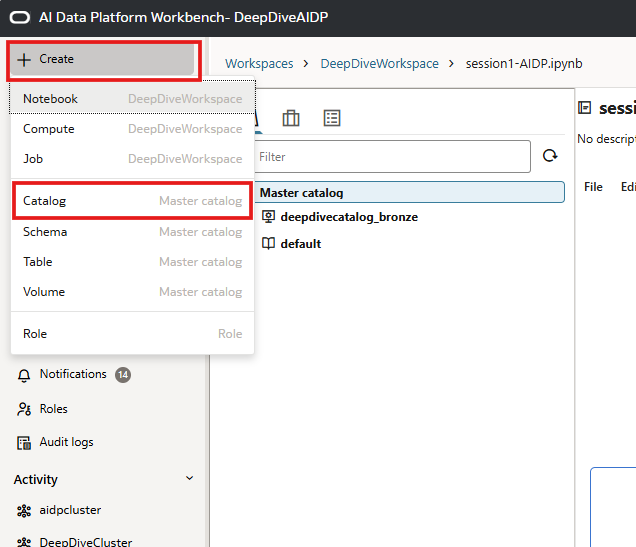  
  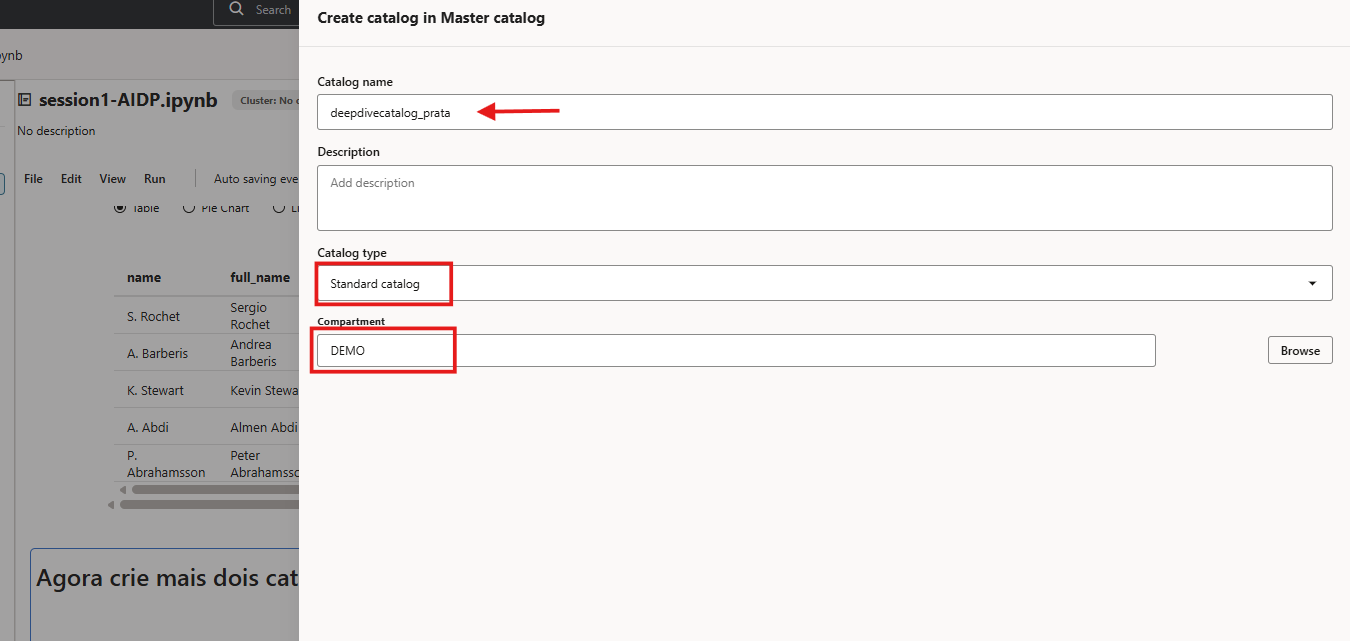
</div>


Repite el proceso nuevamente para crear el catálogo .

---

### Capa Plata
- Refinamiento de los datos
- Estandarización
- Join lógico

### Pre-procesamientos simples

In [141]:
from pyspark.sql.functions import col, to_date

bronze_df = spark.table("deepdivecatalog_bronze.admin.bronze_fifa_players")

silver_df = (bronze_df 
    .withColumn("birth_date", to_date("birth_date", "M/d/yyyy")) 
    .dropDuplicates(["full_name"])  # Remover jogadores duplicados
	.na.replace(float("nan"), None)  # Valores inválidos substituídos por None
	.filter(col("name").isNotNull()) # Remover colunas com nome vazio
)

### Desarrollar columnas derivadas
#### Edad calculada
Como el dataset no es actual, uno de los valores que probablemente está divergente es la edad. Sin embargo, tenemos una columna con la fecha de nacimiento, podemos usarla para crear una columna extra con la edad actualizada.

In [142]:
from pyspark.sql.functions import current_date, year

silver_df = silver_df.withColumn(
    "calculated_age",
    year(current_date()) - year(col("birth_date"))
)

#### Diferencia entre las dos columnas

In [145]:
from pyspark.sql.functions import col, current_date, months_between, abs

silver_df.select(
    "name",
    "age",
    "calculated_age",
    abs(col("age") - col("calculated_age")).alias("age_diff")
).show(5, truncate=False)

+-------------------+---+--------------+--------+
|name               |age|calculated_age|age_diff|
+-------------------+---+--------------+--------+
|Antônio Chiamuloira|31 |38            |7       |
|A. Halme           |20 |28            |8       |
|A. Hughes          |39 |47            |8       |
|A. Lennon          |31 |39            |8       |
|A. Amadi-Holloway  |26 |33            |7       |
+-------------------+---+--------------+--------+
only showing top 5 rows



### Guardando el dataframe procesado en la tabla plata

In [121]:
silver_df.write \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("deepdivecatalog_prata.prata_fifa_players")

---

### Capa Gold
Datos listos para generar valor de negocio. Dashboards, gráficos, machine learning...

#### Crear categorías de calificación de los jugadores

In [163]:
from pyspark.sql.functions import when
from pyspark.sql.functions import col

silver_df = silver_df.withColumn(
    "overall_rating",
    col("overall_rating").cast("int")
)

gold_df = silver_df.withColumn(
    "rating_category",
    when(col("overall_rating") >= 85, "elite")
    .when(col("overall_rating") >= 75, "bom")
    .otherwise("comum")
)

#### Seleccionar columnas relevantes

In [155]:
gold_df = gold_df.select(
    "name",
    "full_name",
    "birth_date",
    "calculated_age",
    "nationality",
    "overall_rating",
    "potential",
    "value_euro",
    "wage_euro",
    "preferred_foot",
    "rating_category"
)

#### Guardar la tabla consolidada en la capa oro

In [156]:
gold_df.write.mode("overwrite").saveAsTable(
    "deepdivecatalog_ouro.ouro_fifa_players"
)

### Armando otras visualizaciones en la capa oro
#### Top jugadores con nombre, nacionalidad, rating y valor

In [164]:
gold_top_players = gold_df \
    .select("name", "nationality", "overall_rating", "value_euro") \
    .orderBy(col("overall_rating").desc()) 
	

display(gold_top_players.limit(10))

### Valor promedio por país

In [165]:
from pyspark.sql.functions import avg

gold_value_by_country = gold_df \
    .groupBy("nationality") \
    .agg(avg("value_euro").alias("avg_value_euro"))

display(gold_value_by_country)

### Jugadores más prometedores

In [166]:
gold_high_potential = gold_df \
    .filter(col("potential") > 85) \
    .select("name", "age", "potential", "value_euro")  

gold_high_potential.head()

Row(name='A. Diallo', age=22, potential=86, value_euro=15000000.0)

### Eficiencia: rating -> salario

In [167]:
gold_efficiency = gold_df \
    .withColumn("value_per_wage", col("value_euro") / col("wage_euro")) \
    .select("name", "value_per_wage", "overall_rating")

### Guardando en la capa oro

In [169]:
gold_top_players.write.mode("overwrite").saveAsTable(
    "deepdivecatalog_ouro.ouro_top_players"
)

gold_value_by_country.write.mode("overwrite").saveAsTable(
    "deepdivecatalog_ouro.ouro_value_by_country"
)

gold_high_potential.write.mode("overwrite").saveAsTable(
    "deepdivecatalog_ouro.ouro_high_potential"
)

gold_efficiency.write.mode("overwrite").saveAsTable(
    "deepdivecatalog_ouro.ouro_efficiency"
)